# Demo 2: Embeddings & Fine-Tuning

Embeddings turn text into vectors where meaning is geometry. Fine-tuning adapts a pre-trained model to a specific domain — and reveals what happens when it hallucinates.

## Part 1: Embeddings

### Setup

In [1]:
%pip install -q sentence-transformers chromadb matplotlib seaborn numpy pandas transformers datasets torch accelerate

%reset -f

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

Note: you may need to restart the kernel to use updated packages.


/home/christopher/projects/datasci_223/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load an Embedding Model

`all-MiniLM-L6-v2` produces 384-dimensional embeddings. For production clinical work you'd want a domain-specific model (e.g., ClinicalBERT), but this works well for understanding the concepts.

In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/103 [00:00<00:00, 11748.75it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/103 [00:00<00:00, 504.67it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   2%|▏         | 2/103 [00:00<00:00, 643.69it/s, Materializing param=embeddings.LayerNorm.weight]

Loading weights:   2%|▏         | 2/103 [00:00<00:00, 288.26it/s, Materializing param=embeddings.LayerNorm.weight]

...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 449.09it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 449.09it/s, Materializing param=pooler.dense.weight]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 636.98it/s, Materializing param=pooler.dense.weight]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384


### Embed Clinical Notes

In [3]:
notes = [
    "58-year-old male with chest pain radiating to the left arm. Troponin elevated at 0.8 ng/mL. ECG shows ST elevation in leads V1-V4. Diagnosis: STEMI.",
    "65-year-old female with polyuria and polydipsia. Fasting glucose 285 mg/dL, HbA1c 9.2%. Assessment: Poorly controlled type 2 diabetes mellitus.",
    "42-year-old male with productive cough for 5 days, fever to 101.5F. Chest X-ray shows right lower lobe infiltrate. Diagnosis: Community-acquired pneumonia.",
    "28-year-old female with severe headache, photophobia, and neck stiffness. Temperature 102.8F. LP shows elevated WBC with neutrophil predominance. Diagnosis: Bacterial meningitis.",
    "72-year-old male with acute onset left-sided weakness and slurred speech. CT head negative for hemorrhage. Onset 2 hours ago. Assessment: Acute ischemic stroke.",
    "55-year-old female with epigastric pain radiating to the back, nausea, vomiting. Lipase elevated at 1200 U/L. Diagnosis: Acute pancreatitis.",
    "Patient presents with crushing chest pain, diaphoresis, and shortness of breath. Cardiac enzymes elevated. Emergency cardiac catheterization planned.",
    "Routine wellness visit. Blood pressure 118/76 mmHg, BMI 24.2. Fasting glucose 92 mg/dL. All screening labs within normal limits.",
]

labels = ["STEMI", "Diabetes", "Pneumonia", "Meningitis", "Stroke", "Pancreatitis", "Cardiac emergency", "Wellness visit"]

embeddings = model.encode(notes)
print(f"Embedded {len(notes)} notes → shape {embeddings.shape}")

Embedded 8 notes → shape (8, 384)


### Pairwise Similarity

Cosine similarity: 1 = identical direction, 0 = unrelated, -1 = opposite.

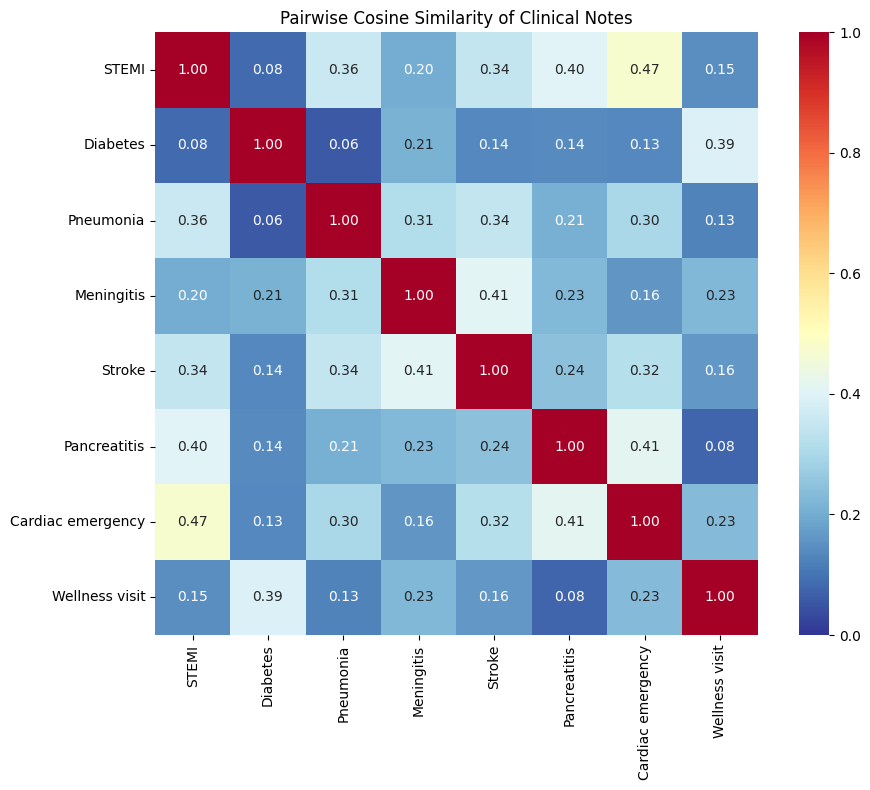

In [4]:
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    square=True,
)
plt.title("Pairwise Cosine Similarity of Clinical Notes")
plt.tight_layout()
plt.show()

The two cardiac cases (STEMI and "Cardiac emergency") cluster together. The wellness visit is distant from everything else. The model captures clinical meaning without any explicit medical training.

### Semantic Search

Traditional keyword search fails when the query uses different words than the document. Semantic search finds conceptually similar documents regardless of exact wording.

In [5]:
def semantic_search(query, notes, embeddings, model, top_k=3):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    ranked = sorted(zip(range(len(notes)), similarities, notes), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# "heart attack" doesn't appear in any note, but STEMI and cardiac emergency should rank high
query = "patient with heart attack symptoms"
print(f"Query: '{query}'\n")
for rank, (idx, score, note) in enumerate(semantic_search(query, notes, embeddings, model), 1):
    print(f"  {rank}. [{labels[idx]}] (similarity: {score:.3f})")
    print(f"     {note[:80]}...\n")

Query: 'patient with heart attack symptoms'

  1. [Cardiac emergency] (similarity: 0.612)
     Patient presents with crushing chest pain, diaphoresis, and shortness of breath....

  2. [STEMI] (similarity: 0.419)
     58-year-old male with chest pain radiating to the left arm. Troponin elevated at...

  3. [Pancreatitis] (similarity: 0.324)
     55-year-old female with epigastric pain radiating to the back, nausea, vomiting....



In [6]:
query = "infectious disease with high fever"
print(f"Query: '{query}'\n")
for rank, (idx, score, note) in enumerate(semantic_search(query, notes, embeddings, model), 1):
    print(f"  {rank}. [{labels[idx]}] (similarity: {score:.3f})")
    print(f"     {note[:80]}...\n")

Query: 'infectious disease with high fever'



  1. [Meningitis] (similarity: 0.474)
     28-year-old female with severe headache, photophobia, and neck stiffness. Temper...

  2. [Pneumonia] (similarity: 0.433)
     42-year-old male with productive cough for 5 days, fever to 101.5F. Chest X-ray ...

  3. [Pancreatitis] (similarity: 0.282)
     55-year-old female with epigastric pain radiating to the back, nausea, vomiting....



### Scaling Up: Vector Databases

The `cosine_similarity` approach works for small collections. For thousands or millions of documents, vector databases build indexes (HNSW, IVF) for approximate nearest-neighbor search in milliseconds. ChromaDB is a lightweight option that runs in-process — same API pattern, just with indexing under the hood.

In [7]:
import chromadb

client = chromadb.Client()
collection = client.create_collection(name="clinical_notes", metadata={"hnsw:space": "cosine"})

collection.add(
    documents=notes,
    ids=[f"note_{i}" for i in range(len(notes))],
    metadatas=[{"label": label} for label in labels],
)

results = collection.query(query_texts=["patient experiencing cardiac arrest"], n_results=3)
for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
    print(f"  [{meta['label']}] (similarity: {1 - dist:.3f}) {doc[:80]}...")

  [Cardiac emergency] (similarity: 0.592) Patient presents with crushing chest pain, diaphoresis, and shortness of breath....
  [STEMI] (similarity: 0.316) 58-year-old male with chest pain radiating to the left arm. Troponin elevated at...
  [Stroke] (similarity: 0.262) 72-year-old male with acute onset left-sided weakness and slurred speech. CT hea...


Other options: FAISS, pgvector, Pinecone. The assignment uses manual cosine similarity since we only have 4 notes.

---

## Part 2: Fine-Tuning a Language Model

Fine-tuning adapts a pre-trained model to a specific domain. We'll fine-tune GPT-2 (the smallest version, 124M parameters) on a tiny set of clinical text — then see what it generates, including hallucinations.

### Load GPT-2

In [8]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import Dataset
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
base_model = GPT2LMHeadModel.from_pretrained("gpt2")

print(f"Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/148 [00:00<00:00, 22795.13it/s, Materializing param=transformer.h.0.attn.c_attn.bias]

Loading weights:   1%|          | 1/148 [00:00<00:00, 897.95it/s, Materializing param=transformer.h.0.attn.c_attn.bias]  

Loading weights:   1%|▏         | 2/148 [00:00<00:00, 638.31it/s, Materializing param=transformer.h.0.attn.c_attn.weight]

Loading weights:   1%|▏         | 2/148 [00:00<00:00, 412.54it/s, Materializing param=transformer.h.0.attn.c_attn.weight]

...

Loading weights:  99%|█████████▉| 147/148 [00:00<00:00, 915.29it/s, Materializing param=transformer.wpe.weight]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 915.29it/s, Materializing param=transformer.wte.weight]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 915.29it/s, Materializing param=transformer.wte.weight]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 957.51it/s, Materializing param=transformer.wte.weight]

Model parameters: 124,439,808
Vocabulary size: 50257


### Generate BEFORE fine-tuning

Base GPT-2 was trained on internet text, not medical data. Here's what it produces for a clinical prompt.

In [9]:
def generate_text(model, prompt, max_new_tokens=100, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

prompt = "Clinical Note: 58-year-old male presenting with"
print("=== Base GPT-2 (no fine-tuning) ===")
print(generate_text(base_model, prompt))

=== Base GPT-2 (no fine-tuning) ===


Clinical Note: 58-year-old male presenting with a benign but potentially life-threatening condition.

U.S. Food and Drug Administration

Patient Information

The following information is for information purposes only and is not a substitute for medical advice or medical advice of your physician or any other health care professional. The information on this page may not be correct and may not reflect the full medical advice or medical advice of your physician. If you have any questions, please contact your local medical center.

Patient Information

There


### Prepare Training Data

We'll fine-tune on a small set of clinical notes. In practice you'd need hundreds or thousands of examples — this tiny dataset is just to demonstrate the mechanics.

In [10]:
clinical_texts = [
    "Clinical Note: 58-year-old male presenting with chest pain radiating to left arm. Troponin 0.8 ng/mL. ECG shows ST elevation V1-V4. Assessment: STEMI. Plan: Emergent cardiac catheterization, aspirin 325mg, heparin drip, cardiology consult.",
    "Clinical Note: 72-year-old female with new-onset confusion and fever 39.1C. WBC 18,000. Urinalysis positive for nitrites and leukocyte esterase. Blood cultures drawn. Assessment: Urosepsis. Plan: IV ceftriaxone, fluid resuscitation, ICU admission.",
    "Clinical Note: 45-year-old male with 3-day history of progressive shortness of breath. O2 sat 88% on room air. CXR bilateral infiltrates. COVID-19 PCR positive. Assessment: COVID-19 pneumonia with hypoxic respiratory failure. Plan: Supplemental O2, prone positioning, dexamethasone.",
    "Clinical Note: 65-year-old female with acute onset right-sided weakness and aphasia. Last known well 90 minutes ago. NIHSS 14. CT head negative for hemorrhage. Assessment: Acute ischemic stroke. Plan: tPA administration, neurology consult, MRI brain.",
    "Clinical Note: 30-year-old female presenting with RUQ pain, nausea, and fever 38.5C. Murphy sign positive. WBC 15,000. RUQ ultrasound shows gallbladder wall thickening and pericholecystic fluid. Assessment: Acute cholecystitis. Plan: NPO, IV antibiotics, surgical consult for cholecystectomy.",
    "Clinical Note: 55-year-old male with poorly controlled type 2 diabetes. HbA1c 10.2%. Fasting glucose 310 mg/dL. Complains of polyuria and blurred vision. Assessment: Uncontrolled T2DM with hyperglycemia. Plan: Insulin initiation, endocrinology referral, diabetic education.",
    "Clinical Note: 40-year-old female with severe headache, worst of life, acute onset. BP 165/95. CT head negative. LP shows xanthochromia. Assessment: Subarachnoid hemorrhage. Plan: CTA head and neck, neurosurgery consult, nimodipine, ICU admission.",
    "Clinical Note: 68-year-old male with melena and hematemesis. HR 110, BP 90/60. Hemoglobin 7.2. Assessment: Upper GI bleed with hemodynamic instability. Plan: 2 units pRBC, IV PPI, GI consult for emergent EGD, ICU admission.",
]

# Tokenize
def tokenize_fn(examples):
    result = tokenizer(examples["text"], truncation=True, max_length=256, padding="max_length")
    result["labels"] = result["input_ids"].copy()
    return result

dataset = Dataset.from_dict({"text": clinical_texts})
tokenized = dataset.map(tokenize_fn, remove_columns=["text"])
print(f"Training examples: {len(tokenized)}")

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map: 100%|██████████| 8/8 [00:00<00:00, 835.75 examples/s]

Training examples: 8


### Fine-Tune

This will only take a minute or two — it's a tiny dataset with a small model.

In [11]:
training_args = TrainingArguments(
    output_dir="./gpt2_clinical",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    learning_rate=5e-5,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
)

trainer = Trainer(
    model=base_model,
    args=training_args,
    train_dataset=tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Fine-tuning GPT-2 on clinical notes...")
trainer.train()
print("Fine-tuning complete!")

Fine-tuning GPT-2 on clinical notes...


/home/christopher/projects/datasci_223/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,3.858250
20,2.616390
30,2.064705
40,1.803640


Fine-tuning complete!


### Generate AFTER fine-tuning

The model has now seen clinical note patterns. Compare to the pre-fine-tuning output above.

In [12]:
prompt = "Clinical Note: 58-year-old male presenting with"
print("=== Fine-tuned GPT-2 ===")
print(generate_text(base_model, prompt))

=== Fine-tuned GPT-2 ===


Clinical Note: 58-year-old male presenting with head and neck pain. Assessment: Acute head pain. Plan: Headache, neck, neck pain, neck neck brace, head and neck pain. Plan: Headache, neck, neck brace, neck CT scan, MRI, head and neck scan. Assessment: Headache, neck pain, head pain, head and neck pain. Plan: Headache, neck pain, CT scan, CT neck referral. Plan: Acute head and neck pain, head and neck pain, neck brace,


In [13]:
# Try a different prompt
prompt = "Clinical Note: 72-year-old female with"
print("=== Fine-tuned GPT-2 ===")
print(generate_text(base_model, prompt))

=== Fine-tuned GPT-2 ===


Clinical Note: 72-year-old female with acute myeloid leukocytosis. Cervical fluid negative for leukocyte leukocyte esterase. Plan: 1 day, 1-month, MRI. Assessment: Acute fluid retention. Plan: Plan B, Plan A, Plan B-C, Plan C, Plan D. Plan: Plan Bile cell transplant, IV antibiotics. Plan: Plan A, Plan Bile cell transplant, IV antibiotics. Plan Bile fluid, IV antibiotics. Plan: Plan A


### Inducing Hallucinations

Now let's push the model outside its training distribution. With only 8 training examples, the model will confidently generate plausible-looking but fabricated clinical details.

In [14]:
# Ask about something not in the training data
hallucination_prompts = [
    "Clinical Note: 12-year-old child presenting with",
    "Clinical Note: Patient with history of liver transplant and",
    "Clinical Note: Pregnant woman at 32 weeks with",
]

print("=== Hallucination examples ===\n")
for prompt in hallucination_prompts:
    print(f"Prompt: {prompt}")
    print(generate_text(base_model, prompt, max_new_tokens=80))
    print("\n" + "-" * 60 + "\n")

=== Hallucination examples ===

Prompt: Clinical Note: 12-year-old child presenting with


Clinical Note: 12-year-old child presenting with fever, headache, dizziness, and fever. Assessment: Acute onset headache with headache. Plan: Headache, neurology, radiograph, chest x-ray, ECG findings. Plan: Nerve, CT, MRI, CT angioplasty visit. Plan: Acute headache, neurology, neurology, radiograph, MRI. Plan: Headache, neurology,

------------------------------------------------------------

Prompt: Clinical Note: Patient with history of liver transplant and


Clinical Note: Patient with history of liver transplant and history of non-alcoholic steatohepatitis. WBC 35.2. Assessment: BP 30.2. Assessment: BP 29.2. Plan: ICU admission. Plan: ICU admission, ICU admission, ICU admission. Plan: ICU admission. Plan: ICU admission, ICU admission. Plan: ICU admission. Assessment: OAIS,

------------------------------------------------------------

Prompt: Clinical Note: Pregnant woman at 32 weeks with


Clinical Note: Pregnant woman at 32 weeks with a history of nausea and vomiting. HGP negative. Plan is IV antibiotics, IV HEP, and IV intravascular coagulation. Plan is chemo-induced nausea and vomiting. Plan is ICU admission. Plan is ICU admission. Plan is on ventilator, ICU admission, ICU admission, admission ICU admission, ICU admission. Plan is: ICU

------------------------------------------------------------



The model generates confident, structured clinical text — but the specific values (lab results, vitals, doses) are fabricated. It learned the _format_ of clinical notes from fine-tuning, but it doesn't have real medical knowledge.

This is the hallucination problem from the lecture: the model extrapolates beyond its training data without knowing it's doing so. There is no general solution — only mitigations (RAG, output validation, human review).
